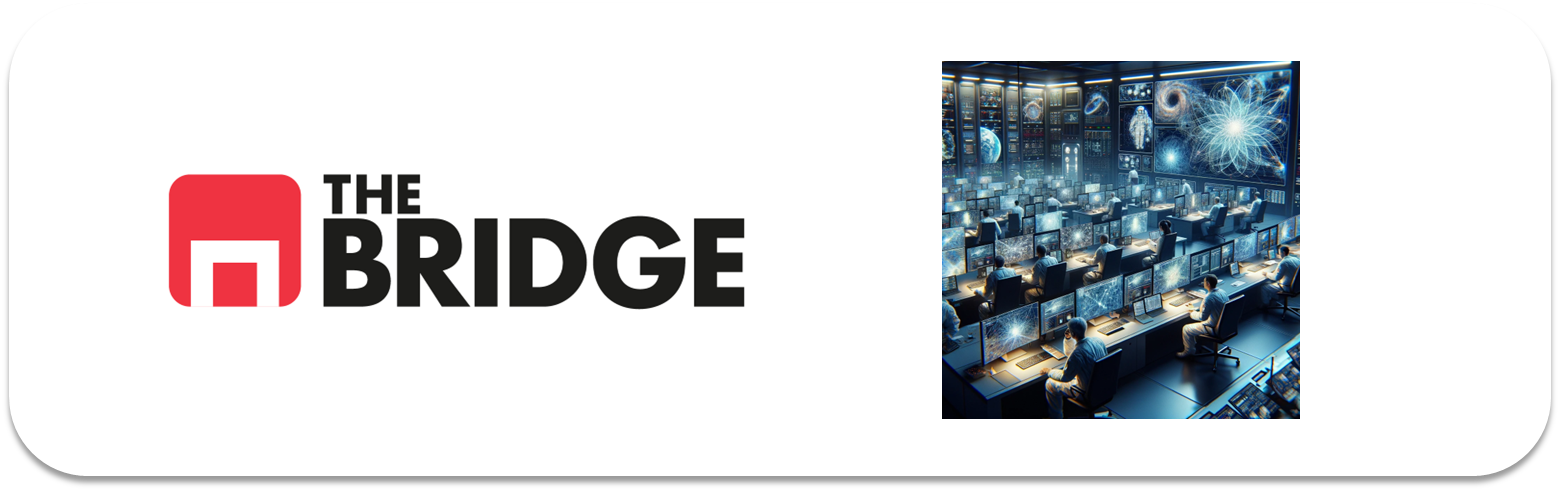

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

print(tf.__version__)

2.21.0


### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



#### Preparación de datos

In [12]:
# Ruta del dataset
data_dir = r"C:\Users\abbal\OneDrive\Documents\GitHub\marzo26DS\DS-online-AnaBelenBalmaseda\DS-online-AnaBelenBalmaseda\05_Deep_Learning\Sprint_16\Unidad_02_CNN_Transfer_Learning_Fine_Tuning\03_Practica_Obligatoria\dataset\seg_train"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset="training",
    class_mode="categorical",
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset="validation",
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())

print(class_names)

Found 11228 images belonging to 1 classes.
Found 2806 images belonging to 1 classes.
['seg_train']


#### Función para visualizar imágenes

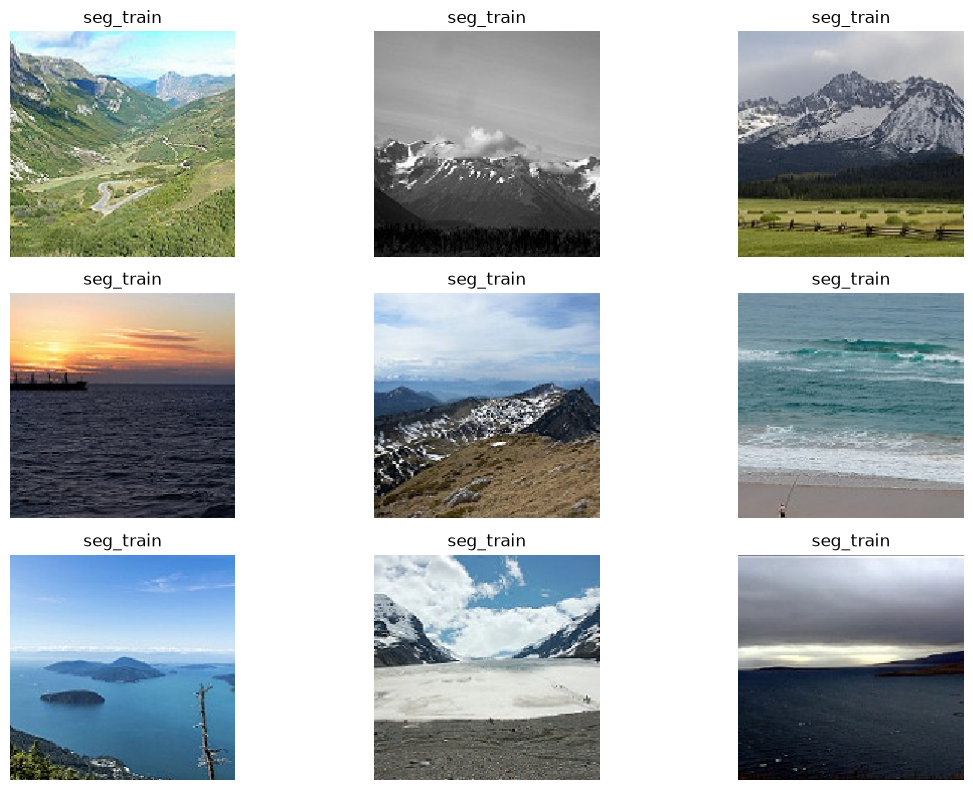

In [13]:
def visualizar_imagenes(generator):

    imagenes, etiquetas = next(generator)

    plt.figure(figsize=(12,8))

    for i in range(9):

        plt.subplot(3,3,i+1)

        img = (imagenes[i]+1)/2
        plt.imshow(img)

        plt.title(class_names[np.argmax(etiquetas[i])])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

visualizar_imagenes(train_generator)

#### TRANSFER LEARNING


In [14]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
x = Dense(64, activation="relu")(x)

output = Dense(len(class_names), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_transfer = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5


c:\Users\abbal\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\ops\nn.py:959: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
c:\Users\abbal\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\losses\losses.py:34: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


351/351 ━━━━━━━━━━━━━━━━━━━━ 106s 293ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 113s 322ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 121s 344ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 117s 333ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 131s 375ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


#### EVALUACIÓN TRANSFER LEARNING

In [16]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
x = Dense(64, activation="relu")(x)

output = Dense(len(class_names), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_transfer = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 138s 377ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 131s 372ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 131s 373ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 126s 358ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 127s 361ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


#### FINE TUNING


In [17]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 142s 384ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 150s 428ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 157s 448ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 163s 465ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 162s 460ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


#### Evaluación Fine Tuning

88/88 ━━━━━━━━━━━━━━━━━━━━ 16s 175ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Accuracy Fine-Tuning: 1.0000
88/88 ━━━━━━━━━━━━━━━━━━━━ 17s 188ms/step
              precision    recall  f1-score   support

   seg_train       1.00      1.00      1.00      2806

    accuracy                           1.00      2806
   macro avg       1.00      1.00      1.00      2806
weighted avg       1.00      1.00      1.00      2806



c:\Users\abbal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


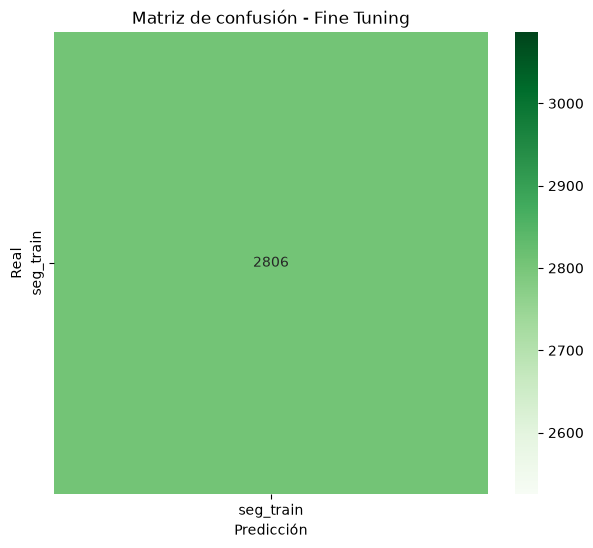

In [20]:
loss, acc = model.evaluate(val_generator)
true_classes = val_generator.classes

print(f"Accuracy Fine-Tuning: {acc:.4f}")

pred = model.predict(val_generator)
pred_classes = np.argmax(pred, axis=1)

print(classification_report(
    true_classes,
    pred_classes,
    target_names=class_names
))

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Matriz de confusión - Fine Tuning")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

#### COMPARACIÓN DE RESULTADOS

88/88 ━━━━━━━━━━━━━━━━━━━━ 16s 184ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Accuracy Fine-Tuning: 1.0000
88/88 ━━━━━━━━━━━━━━━━━━━━ 18s 205ms/step
              precision    recall  f1-score   support

   seg_train       1.00      1.00      1.00      2806

    accuracy                           1.00      2806
   macro avg       1.00      1.00      1.00      2806
weighted avg       1.00      1.00      1.00      2806



c:\Users\abbal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


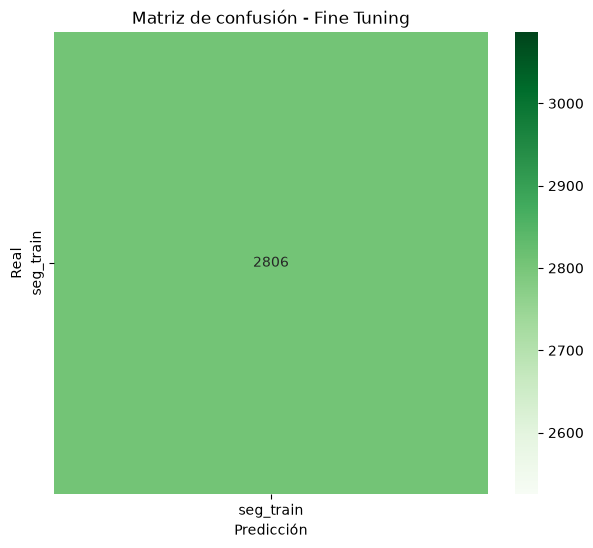

In [21]:
loss, acc = model.evaluate(val_generator)

print(f"Accuracy Fine-Tuning: {acc:.4f}")

pred = model.predict(val_generator)
pred_classes = np.argmax(pred, axis=1)

print(classification_report(
    true_classes,
    pred_classes,
    target_names=class_names
))

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Matriz de confusión - Fine Tuning")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()